# Gemeinsamer Klassifikator: ResNet-18 (Fire)

Trainiert den **einen** Klassifikator, den alle Methoden im Vergleich erklären
(Mirror-CFE, Wachter, CFProto, FCVE): torchvision-ResNet-18, 224×224,
Normierung mean/std = 0.5, Adam 2e-4 — Daten, Klassenregeln und Split identisch
zu allen Methoden-Notebooks.

Export nach `trained_classifiers/resnet18_fire_224.pth`
(reiner torchvision-`state_dict` + Metadaten). Diese Datei neben die
Methoden-Notebooks legen (bzw. auf Kaggle als Input hochladen).

## 1. Setup & Konfiguration

Hyperparameter wie im Paper (Adam $2\cdot10^{-4}$, $\alpha=0.2$, gleiche Verlustgewichte).

**Ausführung auf einem Cluster:**
- Benötigte Pakete: `torch`, `torchvision`, `matplotlib`, `pillow`, `scipy` (FID), `kagglehub` (Datensatz-Download); optional `lpips` für die LPIPS-Metrik.
- Der Datenpfad wird automatisch erkannt (kagglehub-Cache oder `/kaggle/input/...`); sonst wird der Datensatz (~2,8 GB) einmalig per `kagglehub` heruntergeladen — für diesen öffentlichen Datensatz **ohne** Kaggle-Zugangsdaten. Liegt der Datensatz bereits auf dem Cluster, den Pfad (Ordner mit `data/train/images`) in der Umgebungsvariable `MIRROR_FIRE_DATA` setzen.
- Checkpoints landen in `mirror_cfe_checkpoints/`; beim erneuten Ausführen werden sie geladen statt neu trainiert (`RETRAIN_* = True` zum Überschreiben).

**Bildgröße:** Standardmäßig 224×224 — wie in der bestehenden Kaggle-Pipeline; die letzte Feature-Map ist dann 512×7×7. Der Code ist größenunabhängig: Auf schwacher Hardware kann `img_size = 128` gesetzt werden (Paper nutzt 128 für B-MNIST; Feature-Map dann 512×4×4).

In [1]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F          # Achtung: der Encoder des Papers heißt ebenfalls F,
import torchvision                        # hier heißt der Klassifikator deshalb `clf`
import torchvision.transforms.functional as TF
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, Subset, random_split
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt

SEED = 0
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

device = torch.device('cuda' if torch.cuda.is_available()
                      else 'mps' if torch.backends.mps.is_available() else 'cpu')
print('Device:', device)

QUICK_TEST = os.environ.get('MIRROR_QUICK', '0') == '1'

# Kaggle-Datenpfad: fester Organizations-Pfad wie in den anderen Notebooks
# (mirrorcfe-fire.ipynb, fcve-fire-v3.ipynb)
DATA_DIR = '/kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo'
assert os.path.isdir(os.path.join(DATA_DIR, 'data', 'train', 'images')), \
    f'data/train/images nicht gefunden unter {DATA_DIR} - Datensatz als Kaggle-Input hinzufügen.'
print('Datensatz:', DATA_DIR)

NUM_WORKERS = 4 if device.type == 'cuda' else 0   # auf dem Cluster parallel laden

CFG = dict(
    img_size    = 224,                     # wie die bestehende Kaggle-Pipeline (128 als speichersparende Option)
    num_classes = 2,
    class_names = {0: 'fire', 1: 'no_fire'},   # alphabetisch wie ImageFolder in der Vorlage
    batch_size  = 32,
    lr          = 2e-4,                    # Adam (Paper)
    epochs_classifier = 1 if QUICK_TEST else 20,
    ckpt_dir    = 'mirror_cfe_checkpoints',
)
os.makedirs(CFG['ckpt_dir'], exist_ok=True)

RETRAIN_CLASSIFIER = False

suffix    = '_quick' if QUICK_TEST else ''
CLF_CKPT  = os.path.join(CFG['ckpt_dir'], f'resnet18_fire{suffix}.pt')
if QUICK_TEST:
    print('QUICK_TEST aktiv: reduzierte Daten/Epochen (nur Funktionstest!)')

Device: cuda
Datensatz: /kaggle/input/datasets/sayedgamal99/smoke-fire-detection-yolo


## 2. Daten: Fire-Datensatz & Klassenpaar

Klassenzuordnung **identisch zur bestehenden Pipeline** (`mirrorcfe-fire.ipynb`): Ein Bild aus `data/train` ist `fire`, wenn seine YOLO-Labeldatei mindestens eine Box enthält (Achtung: das schließt auch reine Rauch-Boxen ein), sonst `no_fire`. Der Split ist ebenfalls identisch: 80/20 mit `torch.Generator().manual_seed(42)`.

Die Bilder werden auf `IMG_SIZE`² skaliert und auf $[-1,1]$ normiert.

In [2]:
IMG = CFG['img_size']
tfm = transforms.Compose([
    transforms.Resize((IMG, IMG)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),   # -> [-1, 1]
])

def has_boxes(label_path):
    """True, wenn die YOLO-Labeldatei mindestens eine gueltige Box enthaelt."""
    if not os.path.exists(label_path):
        return False
    with open(label_path) as f:
        return any(len(line.strip().split()) >= 5 for line in f)

class FireDataset(Dataset):
    """Liest data/train direkt (ohne Umkopieren): fire=0 (mit Box), no_fire=1."""

    def __init__(self, root, transform):
        self.transform = transform
        img_dir  = Path(root) / 'data' / 'train' / 'images'
        lbl_dir  = Path(root) / 'data' / 'train' / 'labels'
        exts = {'.jpg', '.jpeg', '.png', '.bmp', '.tif', '.tiff'}
        self.samples = []
        for p in sorted(img_dir.iterdir()):
            if p.suffix.lower() in exts:
                y = 0 if has_boxes(lbl_dir / (p.stem + '.txt')) else 1
                self.samples.append((p, y))
        self.targets = [y for _, y in self.samples]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, i):
        p, y = self.samples[i]
        img = Image.open(p).convert('RGB')
        return self.transform(img), y

full_ds = FireDataset(DATA_DIR, tfm)
n_fire = sum(1 for y in full_ds.targets if y == 0)
print(f'Gesamt: {len(full_ds)} Bilder | fire: {n_fire} | no_fire: {len(full_ds) - n_fire}')

# 80/20-Split, Seed 42 - identisch zur bestehenden Pipeline
n_val = int(len(full_ds) * 0.2)
gen42 = torch.Generator().manual_seed(42)
train_split, val_split = random_split(full_ds, [len(full_ds) - n_val, n_val], generator=gen42)

train_idx = list(train_split.indices)
val_idx   = list(val_split.indices)
if QUICK_TEST:
    train_idx, val_idx = train_idx[:256], val_idx[:128]

pair_train_loader = DataLoader(Subset(full_ds, train_idx), batch_size=CFG['batch_size'],
                               shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
pair_test_loader  = DataLoader(Subset(full_ds, val_idx), batch_size=64,
                               shuffle=False, num_workers=NUM_WORKERS)

# binaeres Klassenpaar: fire <-> no_fire
pair_of = {0: 1, 1: 0}

# Index-Pools je Klasse (Trainingssplit) fuer x_t / x_ss im Triangulationsverlust
class_pool = {c: [i for i in train_idx if full_ds.targets[i] == c] for c in (0, 1)}

def sample_class_images(labels):
    """Zieht zu jedem Label ein zufaelliges echtes Trainingsbild dieser Klasse."""
    idx = [random.choice(class_pool[int(c)]) for c in labels]
    return torch.stack([full_ds[i][0] for i in idx])

print(f'Train: {len(train_idx)} | Val: {len(val_idx)}')

Gesamt: 14122 Bilder | fire: 7664 | no_fire: 6458
Train: 11298 | Val: 2824


## 3. Klassifikator $F$: ResNet-18

Torchvision-ResNet-18 mit Standard-Stem (7×7-Faltung + MaxPool) für RGB-Bilder. Bei 224×224-Eingaben ist die letzte Feature-Map $\mathbf{f}^l$ **512×7×7**; alle Methoden-Bausteine sind größenunabhängig. Skip-Features: $\mathbf{f}^1$ (64×56×56), $\mathbf{f}^2$ (128×28×28), $\mathbf{f}^3$ (256×14×14).

In [3]:
class ResNet18Fire(nn.Module):
    """Torchvision-ResNet-18 (Standard-Stem) mit Feature-Zugriff wie in der MNIST-Version."""

    def __init__(self, num_classes=2):
        super().__init__()
        self.base = torchvision.models.resnet18(weights=None, num_classes=num_classes)

    def features(self, x):
        """[f1, f2, f3, f4]: (64,56,56), (128,28,28), (256,14,14), (512,7,7) bei 224er-Eingabe."""
        b = self.base
        x = b.maxpool(b.relu(b.bn1(b.conv1(x))))
        f1 = b.layer1(x)
        f2 = b.layer2(f1)
        f3 = b.layer3(f2)
        f4 = b.layer4(f3)
        return [f1, f2, f3, f4]

    def encode(self, x):
        """z = GAP(f^l)"""
        return self.features(x)[-1].mean(dim=(2, 3))

    def forward(self, x):
        return self.base.fc(self.encode(x))

clf = ResNet18Fire(CFG['num_classes']).to(device)
print(sum(p.numel() for p in clf.parameters()) / 1e6, 'Mio. Parameter')

11.177538 Mio. Parameter


In [4]:
def test_accuracy(model, loader):
    model.eval()
    correct = total = 0
    per_class = {0: [0, 0], 1: [0, 0]}
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            pred = model(x).argmax(1)
            correct += (pred == y).sum().item(); total += len(y)
            for c in (0, 1):
                m = y == c
                per_class[c][0] += (pred[m] == c).sum().item()
                per_class[c][1] += int(m.sum())
    return correct / total, {c: v[0] / max(v[1], 1) for c, v in per_class.items()}

history = {'train_loss': [], 'test_acc': []}

if os.path.exists(CLF_CKPT) and not RETRAIN_CLASSIFIER:
    clf.load_state_dict(torch.load(CLF_CKPT, map_location=device))
    print('Klassifikator aus Checkpoint geladen (keine Trainingshistorie verfügbar).')
else:
    opt = torch.optim.Adam(clf.parameters(), lr=CFG['lr'])   # Adam 2e-4 (Paper)
    for epoch in range(CFG['epochs_classifier']):
        clf.train()
        running_loss, n_batches = 0.0, 0
        for x, y in pair_train_loader:
            x, y = x.to(device), y.to(device)
            loss = F.cross_entropy(clf(x), y)
            opt.zero_grad(); loss.backward(); opt.step()
            running_loss += loss.item(); n_batches += 1
        epoch_loss = running_loss / n_batches
        epoch_acc, _ = test_accuracy(clf, pair_test_loader)
        history['train_loss'].append(epoch_loss)
        history['test_acc'].append(epoch_acc)
        print(f'Epoche {epoch + 1}/{CFG["epochs_classifier"]} '
              f'- Train-Loss: {epoch_loss:.4f} - Val-Acc: {epoch_acc:.4f}')
    torch.save(clf.state_dict(), CLF_CKPT)

acc, per_class = test_accuracy(clf, pair_test_loader)
print(f'Val-Genauigkeit: {acc:.4f} | fire: {per_class[0]:.4f} | no_fire: {per_class[1]:.4f}')

# Klassifikator einfrieren: F ist reiner Encoder/Entscheider und wird NIE feinjustiert (Faithfulness).
for p in clf.parameters():
    p.requires_grad_(False)
clf.eval()

W_fc = clf.base.fc.weight.detach()   # W  (2 x 512)
b_fc = clf.base.fc.bias.detach()     # b  (2)

Epoche 1/20 - Train-Loss: 0.5139 - Val-Acc: 0.7925
Epoche 2/20 - Train-Loss: 0.3509 - Val-Acc: 0.8523
Epoche 3/20 - Train-Loss: 0.2651 - Val-Acc: 0.8619
Epoche 4/20 - Train-Loss: 0.2055 - Val-Acc: 0.8895
Epoche 5/20 - Train-Loss: 0.1512 - Val-Acc: 0.8948
Epoche 6/20 - Train-Loss: 0.1416 - Val-Acc: 0.9093
Epoche 7/20 - Train-Loss: 0.1060 - Val-Acc: 0.8984
Epoche 8/20 - Train-Loss: 0.0995 - Val-Acc: 0.9090
Epoche 9/20 - Train-Loss: 0.0761 - Val-Acc: 0.8945
Epoche 10/20 - Train-Loss: 0.0802 - Val-Acc: 0.9129
Epoche 11/20 - Train-Loss: 0.0701 - Val-Acc: 0.8892
Epoche 12/20 - Train-Loss: 0.0589 - Val-Acc: 0.9186
Epoche 13/20 - Train-Loss: 0.0537 - Val-Acc: 0.9083
Epoche 14/20 - Train-Loss: 0.0619 - Val-Acc: 0.9079
Epoche 15/20 - Train-Loss: 0.0557 - Val-Acc: 0.9047
Epoche 16/20 - Train-Loss: 0.0490 - Val-Acc: 0.9129
Epoche 17/20 - Train-Loss: 0.0441 - Val-Acc: 0.9090
Epoche 18/20 - Train-Loss: 0.0411 - Val-Acc: 0.8902
Epoche 19/20 - Train-Loss: 0.0504 - Val-Acc: 0.9111
Epoche 20/20 - Train-

### Trainingskurven & Confusion Matrix

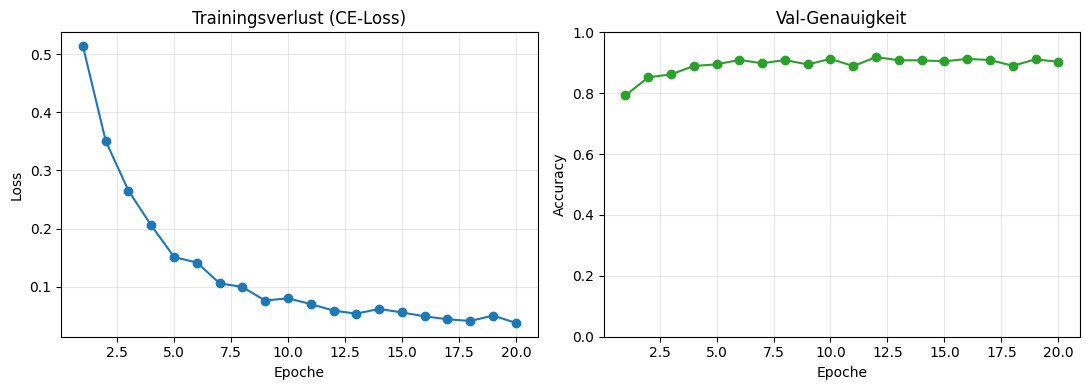

In [5]:
if history['train_loss']:
    epochs_range = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))

    axes[0].plot(epochs_range, history['train_loss'], marker='o', color='tab:blue')
    axes[0].set_title('Trainingsverlust (CE-Loss)')
    axes[0].set_xlabel('Epoche'); axes[0].set_ylabel('Loss'); axes[0].grid(alpha=0.3)

    axes[1].plot(epochs_range, history['test_acc'], marker='o', color='tab:green')
    axes[1].set_title('Val-Genauigkeit')
    axes[1].set_xlabel('Epoche'); axes[1].set_ylabel('Accuracy')
    axes[1].set_ylim(0, 1); axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig('training_curves_fire.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Keine Trainingshistorie vorhanden (Checkpoint wurde geladen statt neu trainiert). '
          'Setze RETRAIN_CLASSIFIER = True, um die Kurven zu erzeugen.')

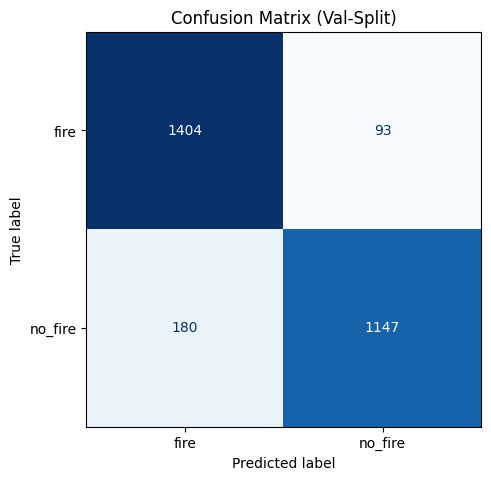

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

clf.eval()
all_preds, all_labels = [], []
with torch.no_grad():
    for x, y in pair_test_loader:
        x = x.to(device)
        preds = clf(x).argmax(1).cpu()
        all_preds.append(preds)
        all_labels.append(y)
all_preds = torch.cat(all_preds).numpy()
all_labels = torch.cat(all_labels).numpy()

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=[CFG['class_names'][0], CFG['class_names'][1]])

fig, ax = plt.subplots(figsize=(5, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False, values_format='d')
ax.set_title('Confusion Matrix (Val-Split)')
plt.tight_layout()
plt.savefig('confusion_matrix_fire.png', dpi=150, bbox_inches='tight')
plt.show()

### Klassifikator-Export für andere Methoden

Der trainierte ResNet-18 wird zusätzlich als **portabler Checkpoint** unter `trained_classifiers/` gespeichert: ein reiner torchvision-`state_dict` (ohne Wrapper-Präfix) plus Metadaten (Bildgröße, Normierung, Klassennamen, Split, Genauigkeit). Andere Methoden (z. B. Wachter, CFProto, FCVE) können ihn so laden:

```python
import torch, torchvision
ckpt  = torch.load('trained_classifiers/resnet18_fire_224.pth', map_location='cpu')
model = torchvision.models.resnet18(num_classes=len(ckpt['class_names']))
model.load_state_dict(ckpt['model_state_dict'])
model.eval()
# Eingaben: RGB, ckpt['img_size']², normiert mit ckpt['normalization_mean']/_std (also [-1,1])
```

In [7]:
# Portabler Export: reiner torchvision-state_dict + Metadaten, damit derselbe
# Klassifikator auch von anderen (CFE-)Methoden wiederverwendet werden kann.
os.makedirs('trained_classifiers', exist_ok=True)
EXPORT_PATH = os.path.join('trained_classifiers', f'resnet18_fire_{IMG}{suffix}.pth')
torch.save({
    'model_state_dict': {k.replace('base.', '', 1): v.cpu()
                          for k, v in clf.state_dict().items()},
    'arch': 'torchvision resnet18(num_classes=2)',
    'dataset': 'smoke-fire-detection-yolo (fire=0 / no_fire=1, Box-Regel wie mirrorcfe-fire.ipynb)',
    'img_size': IMG,
    'normalization_mean': [0.5, 0.5, 0.5],
    'normalization_std':  [0.5, 0.5, 0.5],
    'class_names': CFG['class_names'],
    'split': '80/20, torch.Generator(seed=42)',
    'test_accuracy': acc,
    'per_class_accuracy': per_class,
}, EXPORT_PATH)
print('Klassifikator exportiert:', EXPORT_PATH)

Klassifikator exportiert: trained_classifiers/resnet18_fire_224.pth
